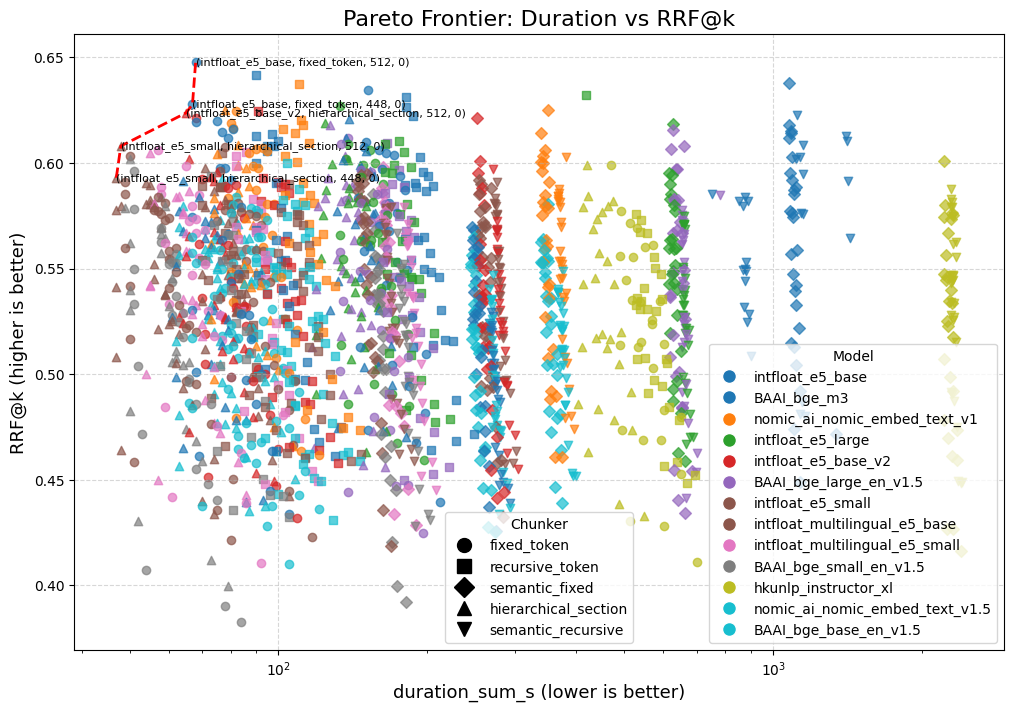


Pareto frontier configurations (fastest → most accurate):
- model=intfloat_e5_small | chunker=hierarchical_section | size=448 | overlap=0 | duration=47.00s | RRF@k=0.593
- model=intfloat_e5_small | chunker=hierarchical_section | size=512 | overlap=0 | duration=48.00s | RRF@k=0.608
- model=intfloat_e5_base_v2 | chunker=hierarchical_section | size=512 | overlap=0 | duration=65.00s | RRF@k=0.624
- model=intfloat_e5_base | chunker=fixed_token | size=448 | overlap=0 | duration=67.00s | RRF@k=0.628
- model=intfloat_e5_base | chunker=fixed_token | size=512 | overlap=0 | duration=68.00s | RRF@k=0.648

Unique models on frontier: intfloat_e5_base, intfloat_e5_base_v2, intfloat_e5_small
Unique chunkers on frontier: fixed_token, hierarchical_section


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# 1. Read the combined CSV
df = pd.read_csv("../artifacts/combined.csv")

# 2. Assign colors and markers
models = df["model_name"].unique()
chunkers = df["chunker_y"].unique()

colors = plt.cm.tab10(np.linspace(0, 1, len(models)))
markers = ['o', 's', 'D', '^', 'v', 'P', 'X', '*']

model_color_map = {m: c for m, c in zip(models, colors)}
chunker_marker_map = {c: markers[i % len(markers)] for i, c in enumerate(chunkers)}

# 3. Build Pareto frontier
df_sorted = df.sort_values(by="duration_sum_s", ascending=True).reset_index(drop=True)
pareto_points = []
max_rrf = -float('inf')
for _, row in df_sorted.iterrows():
    if row["RRF@k"] > max_rrf:
        pareto_points.append(row)
        max_rrf = row["RRF@k"]

pareto_df = pd.DataFrame(pareto_points)

# 4. Plot all points (original style)
plt.figure(figsize=(12, 8))
for _, row in df.iterrows():
    plt.scatter(
        row["duration_sum_s"], row["RRF@k"],
        color=model_color_map[row["model_name"]],
        marker=chunker_marker_map[row["chunker_y"]],
        alpha=0.7
    )

# 5. Connect Pareto frontier points with a line
plt.plot(
    pareto_df["duration_sum_s"],
    pareto_df["RRF@k"],
    color="red",
    linewidth=2,
    linestyle='--',
    label="Pareto Frontier"
)

# 6. ✅ Label Pareto points with full info
for _, row in pareto_df.iterrows():
    label = f"({row['model_name']}, {row['chunker_y']}, {row['size']}, {row['overlap_y']})"
    plt.text(
        row["duration_sum_s"],
        row["RRF@k"],
        label,
        fontsize=8,
        ha='left',
        va='center'
    )

# 7. Legends
model_handles = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor=model_color_map[m], label=m, markersize=10)
    for m in models
]
chunker_handles = [
    Line2D([0], [0], marker=chunker_marker_map[c], color='black',
           linestyle='None', label=c, markersize=10)
    for c in chunkers
]

first_legend = plt.legend(handles=model_handles, title="Model", loc="lower right")
plt.gca().add_artist(first_legend)
plt.legend(handles=chunker_handles, title="Chunker", loc="lower center")

# 8. Styling
plt.title("Pareto Frontier: Duration vs RRF@k", fontsize=16)
plt.xlabel("duration_sum_s (lower is better)", fontsize=13)
plt.ylabel("RRF@k (higher is better)", fontsize=13)
plt.grid(True, linestyle="--", alpha=0.5)
plt.xscale("log")

plt.show()


# --- AFTER pareto_df = pd.DataFrame(pareto_points)

# 6b. Print the Pareto frontier configs
if pareto_df.empty:
    print("No Pareto frontier points found.")
else:
    cols = ["duration_sum_s", "RRF@k", "model_name", "chunker_y", "size", "overlap_y"]
    out = pareto_df[cols].sort_values(["duration_sum_s", "RRF@k"], ascending=[True, False])

    print("\nPareto frontier configurations (fastest → most accurate):")
    for _, r in out.iterrows():
        print(
            f"- model={r['model_name']} | chunker={r['chunker_y']} | "
            f"size={r['size']} | overlap={r['overlap_y']} | "
            f"duration={r['duration_sum_s']:.2f}s | RRF@k={r['RRF@k']:.3f}"
        )

    # (Optional) quick summaries
    print("\nUnique models on frontier:", ", ".join(sorted(map(str, out['model_name'].unique()))))
    print("Unique chunkers on frontier:", ", ".join(sorted(map(str, out['chunker_y'].unique()))))



/tmp/ipykernel_3121020/35734700.py:95: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", len(sub))


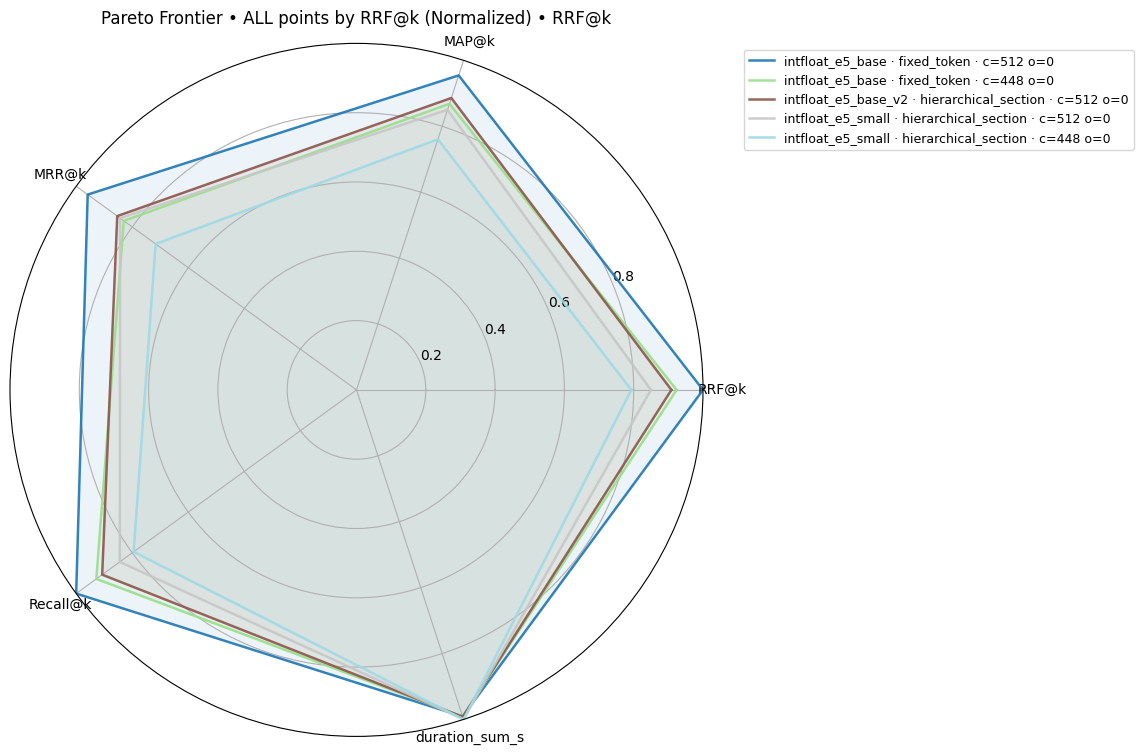

Saved: ../artifacts/fig_radar_pareto_all.png


In [3]:
# ---------- Radar on Pareto Frontier: ALL frontier points (normalized) ----------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def _safe_num(s):
    return pd.to_numeric(s, errors="coerce")

def pick_metric(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    for col in df.columns:
        if "RRF" in col.upper():
            return col
    raise ValueError("No suitable primary metric found.")

def metric_title(df, metric):
    return metric

def savefig(fig, name):
    out = f"../artifacts/{name}.png"
    fig.savefig(out, bbox_inches="tight", dpi=200)
    print(f"Saved: {out}")

if pareto_df.empty:
    print("Pareto frontier is empty; cannot draw radar.")
else:
    # choose a primary metric available on the frontier
    primary_candidates = ["RRF@k", "NDCG@k", "MAP@k", "MRR@k", "Recall@k"]
    primary_metric = pick_metric(pareto_df, primary_candidates)

    # metric pool (False = lower is better → inverted after normalization)
    metric_pool = [
        ("RRF@k", True),
        ("NDCG@k", True),
        ("MAP@k", True),
        ("MRR@k", True),
        ("Recall@k", True),
        ("Precision@1", True),
        ("Precision@10", True),
        ("cost_norm", False),
        ("duration_sum_s", False),
    ]
    metrics = [(m, hb) for (m, hb) in metric_pool if m in df.columns]
    if len(metrics) < 3:
        raise ValueError("Radar needs at least 3 metrics present in df.")

    # include ALL frontier rows, sorted by primary metric (best first)
    sub = pareto_df.sort_values(primary_metric, ascending=False).reset_index(drop=True)

    # normalize each metric using the full dataset range
    norm_vals, metric_names = [], []
    for name, higher_better in metrics:
        full = _safe_num(df[name])
        lo, hi = np.nanmin(full.values), np.nanmax(full.values)
        rng = hi - lo
        if not np.isfinite(lo) or not np.isfinite(hi) or rng <= 0:
            vals = pd.Series(0.5, index=sub.index)  # constant/invalid → neutral
        else:
            vals = (_safe_num(sub[name]) - lo) / rng
            if not higher_better:
                vals = 1.0 - vals
            vals = vals.fillna(0.5).clip(0, 1)
        norm_vals.append(vals.values)
        metric_names.append(name)

    data = np.vstack(norm_vals)  # [num_metrics, num_frontier_points]

    # labels
    def as_int_or_q(x):
        try:
            return str(int(x))
        except Exception:
            return "?"

    labels = []
    for _, row in sub.iterrows():
        model = row.get("model_name", row.get("model_short", "?"))
        chunker = row.get("chunker_y", row.get("chunker", "?"))
        size = as_int_or_q(row.get("size", row.get("token_size", "?")))
        overlap = as_int_or_q(row.get("overlap_y", row.get("overlap", "?")))
        labels.append(f"{model} · {chunker} · c={size} o={overlap}")

    # radar angles
    angles = np.linspace(0, 2*np.pi, len(metric_names), endpoint=False).tolist()
    angles += angles[:1]

    # plotting
    fig = plt.figure(figsize=(9, 9))
    ax = plt.subplot(111, polar=True)

    # a colormap to cycle through many lines if needed
    cmap = plt.cm.get_cmap("tab20", len(sub))
    for i in range(len(sub)):
        vals = data[:, i].tolist()
        vals += vals[:1]
        ax.plot(angles, vals, linewidth=1.8, alpha=0.9, label=labels[i], color=cmap(i))
        ax.fill(angles, vals, alpha=0.08, color=cmap(i))

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(metric_names)
    ax.set_yticks([0.2, 0.4, 0.6, 0.8])
    ax.set_ylim(0, 1)
    ax.set_title(
        f"Pareto Frontier • ALL points by {primary_metric} (Normalized) • {metric_title(df, primary_metric)}",
        pad=14
    )

    # if there are many lines, move legend outside & allow scrolling via ncol
    ncols = 1 if len(sub) <= 10 else 2 if len(sub) <= 20 else 3
    ax.legend(bbox_to_anchor=(1.05, 1.0), loc="upper left", ncol=ncols, fontsize=9)

    plt.show()
    savefig(fig, "fig_radar_pareto_all")
    plt.close(fig)
